# Разведочный анализ данных (EDA)

In [ ]:
# Базовые импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('retail_sales_mock_data.csv')
df.head()

,Date,SalesAmount,Promotion,HolidayMonth
0,2020-01-01,12248,0,0
1,2020-02-01,13011,0,0
2,2020-03-01,12722,0,0
3,2020-04-01,14030,1,0
4,2020-05-01,7783,0,0


In [ ]:
# Установим дату как индекс
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


In [ ]:
df.describe()

,SalesAmount,Promotion,HolidayMonth
count,48.000000,48.000000,48.000000
mean,11768.541667,0.125000,0.083333
std,2257.544863,0.334219,0.279310
min,7783.000000,0.000000,0.000000
25%,10219.750000,0.000000,0.000000
50%,11851.000000,0.000000,0.000000
75%,13014.000000,0.000000,0.000000
max,17996.000000,1.000000,1.000000


Данные представляют собой временной ряд из 48 месяцев с умеренной вариативностью продаж. Акции и праздничные месяцы встречаются относительно редко, но их влияние на продажи потенциально может быть значимым.

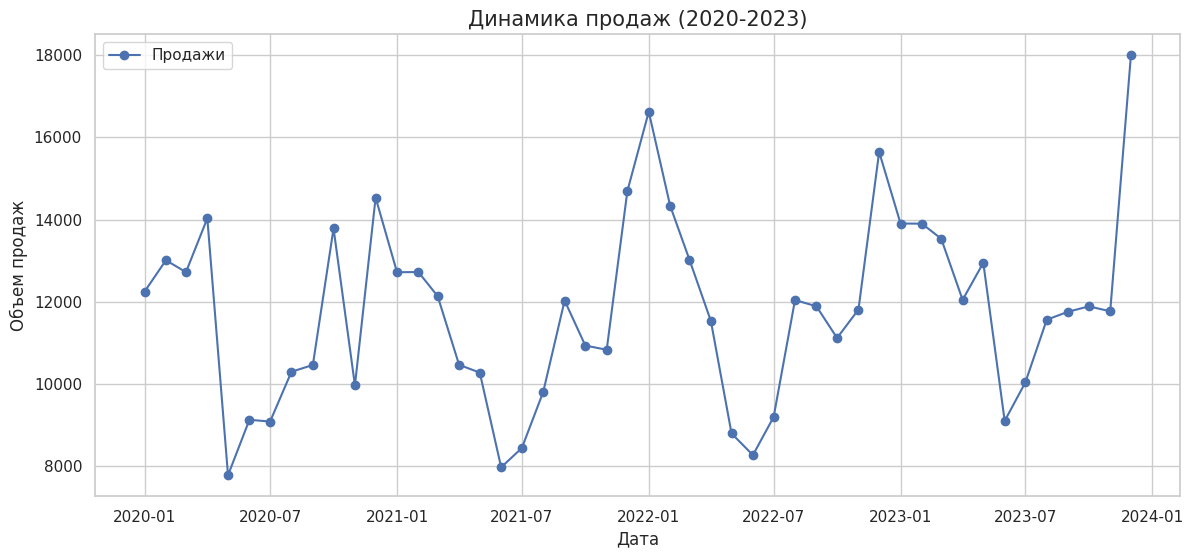

In [ ]:
# Установка стиля
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)



# Линейный график (Общий тренд)
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['SalesAmount'], marker='o', linestyle='-', color='b', label='Продажи')
plt.title('Динамика продаж (2020-2023)', fontsize=15)
plt.xlabel('Дата')
plt.ylabel('Объем продаж')
plt.legend()
plt.show()

 За четыре года возможно незначительное повышение или понижение общего уровня продаж. Продажи демонстрируют умеренную волатильность с наличием сезонных паттернов и редких, но заметных пиков, вероятно обусловленных маркетинговыми активностями или праздниками.

/tmp/ipykernel_206/121834968.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='SalesAmount', data=df, palette='viridis')


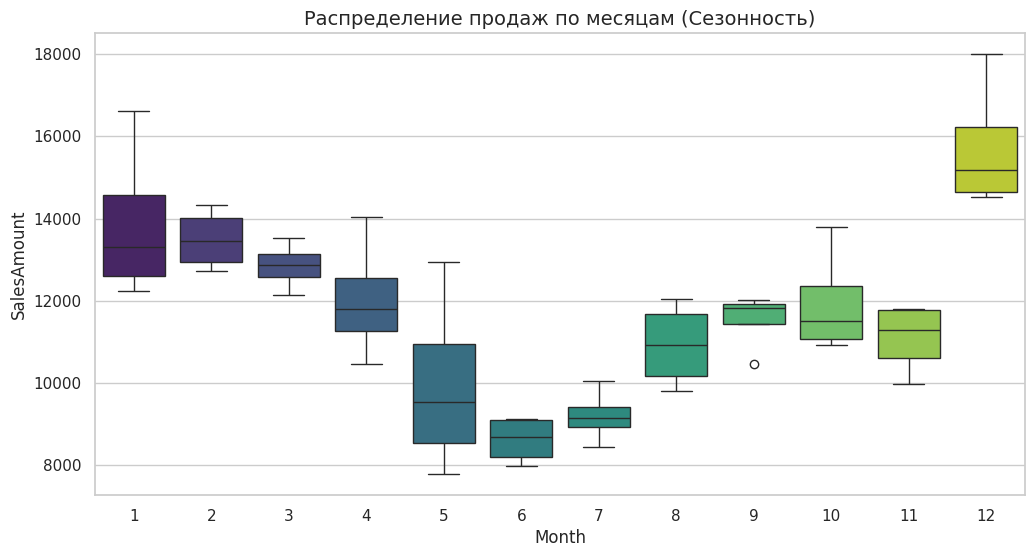

In [ ]:
# Сезонный график (Boxplot по месяцам)
df['Month'] = df.index.month
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='SalesAmount', data=df, palette='viridis')
plt.title('Распределение продаж по месяцам (Сезонность)', fontsize=14)
plt.show()

 На графике видно, что уровни продаж различаются в зависимости от месяца: наблюдаются пики в предпраздничные периоды (декабрь) и спады в межсезонье. Такая повторяющаяся картина подтверждает наличие сезонной компоненты, которую необходимо учитывать при прогнозировании

/tmp/ipykernel_206/545680322.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Promotion', y='SalesAmount', data=df, ci=None, palette='magma')
/tmp/ipykernel_206/545680322.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Promotion', y='SalesAmount', data=df, ci=None, palette='magma')


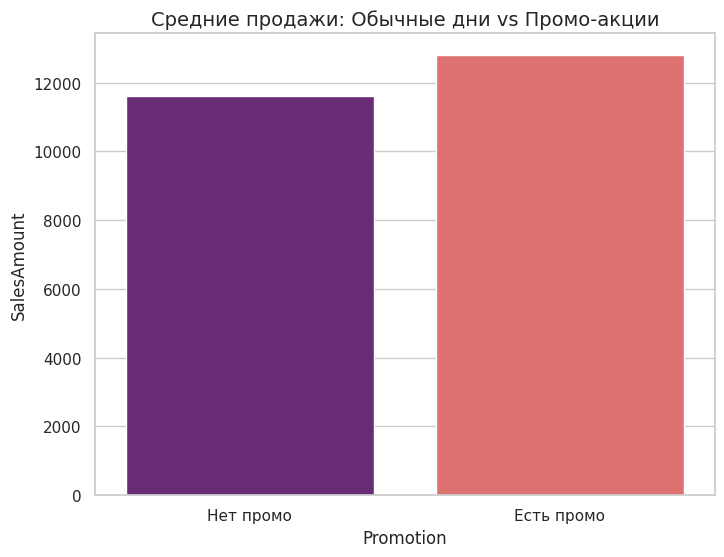

In [ ]:
# Влияние промо-акций (Сравнение средних)
plt.figure(figsize=(8, 6))
sns.barplot(x='Promotion', y='SalesAmount', data=df, ci=None, palette='magma')
plt.title('Средние продажи: Обычные дни vs Промо-акции', fontsize=14)
plt.xticks([0, 1], ['Нет промо', 'Есть промо'])
plt.show()

Сравнение средних продаж в месяцы с промо-акциями и без них показывает значительное различие: при проведении акций средний объём продаж значительно выше. Это указывает на положительную связь между маркетинговыми мероприятиями и уровнем продаж.

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['SalesAmount'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
# Если p-value > 0.05, ряд нестационарен и нужно дифференцирование (d=1)

ADF Statistic: -4.5141835977339575
p-value: 0.00018535586430261453


Вывод: p-value <= 0.05. Ряд стационарен.

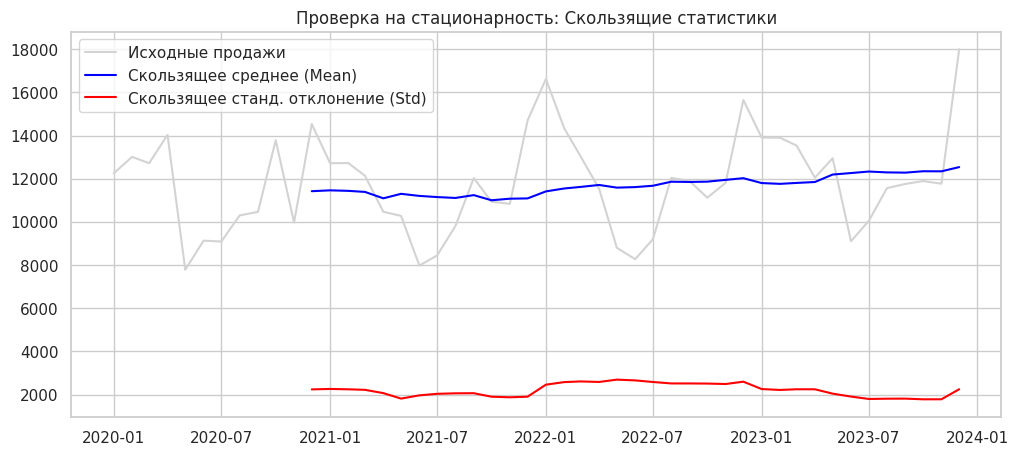

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Скользящее среднее и дисперсия (стандартное отклонение)
window_size = 12 # Годовое окно
rolling_mean = df['SalesAmount'].rolling(window=window_size).mean()
rolling_std = df['SalesAmount'].rolling(window=window_size).std()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['SalesAmount'], color='lightgrey', label='Исходные продажи')
plt.plot(df.index, rolling_mean, color='blue', label='Скользящее среднее (Mean)')
plt.plot(df.index, rolling_std, color='red', label='Скользящее станд. отклонение (Std)')
plt.title('Проверка на стационарность: Скользящие статистики')
plt.legend()
plt.show()

Визуальный анализ скользящих статистик показывает колебания среднего и дисперсии во времени. Это может объясняться детерминированной сезонностью (повторяющиеся пики в определённые месяцы) и условной гетероскедастичностью (изменчивость дисперсии), которые не нарушают стационарность в строгом смысле, но требуют учёта в моделях. Таким образом, ряд стационарен по критерию ADF, но содержит сезонные паттерны и непостоянную дисперсию, что типично для многих экономических временных рядов.

In [ ]:
# Устанавливаем частоту начало месяца
df = df.asfreq('MS')

# Извлекаем ряд продаж для дальнейшего анализа
series = df['SalesAmount']

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL

def render_decomposition(result, title):
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

    result.observed.plot(ax=axes[0], color='black', legend=False)
    axes[0].set_ylabel('Наблюдения')

    result.trend.plot(ax=axes[1], color='blue', legend=False)
    axes[1].set_ylabel('Тренд')

    result.seasonal.plot(ax=axes[2], color='green', legend=False)
    axes[2].set_ylabel('Сезонность')

    result.resid.plot(ax=axes[3], color='red', style='o', markersize=4, legend=False)
    axes[3].set_ylabel('Остатки')

    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.suptitle(title, fontsize=16, y=0.98)
    plt.show()

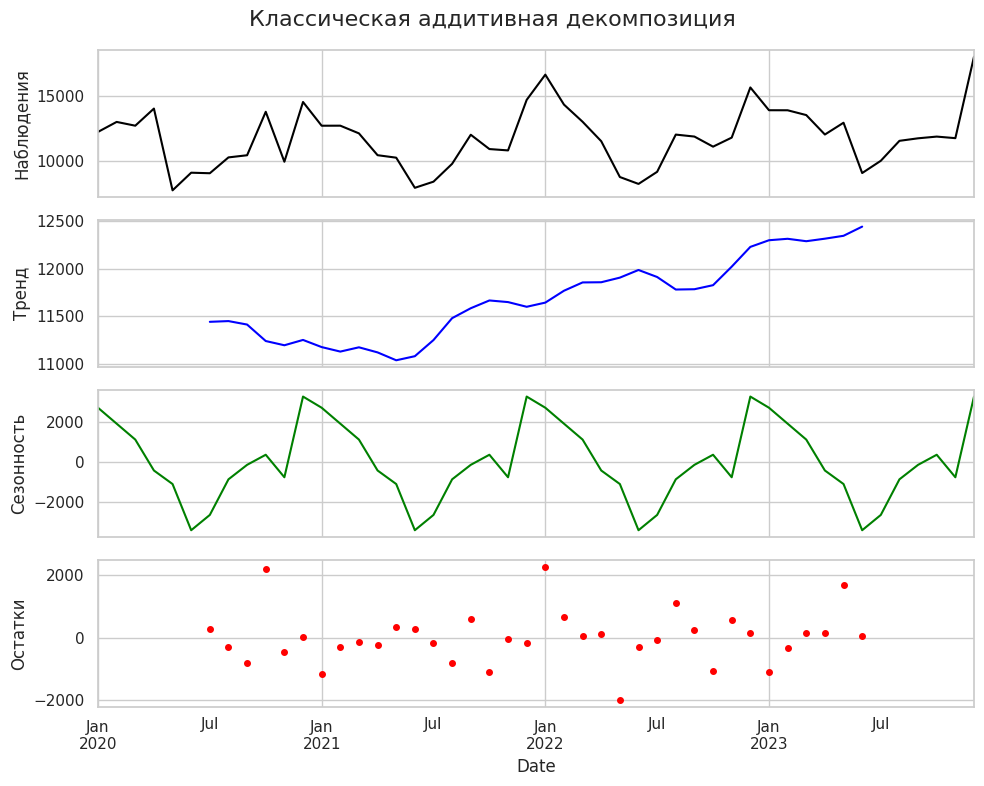

In [ ]:
result_add = seasonal_decompose(series, model='additive')
render_decomposition(result_add, "Классическая аддитивная декомпозиция")

Аддитивная декомпозиция представила ряд как простую сумму компонентов, где сезонные колебания (пики в декабре) имеют фиксированную амплитуду независимо от общего уровня продаж, что делает её удобной для стабильных рынков.

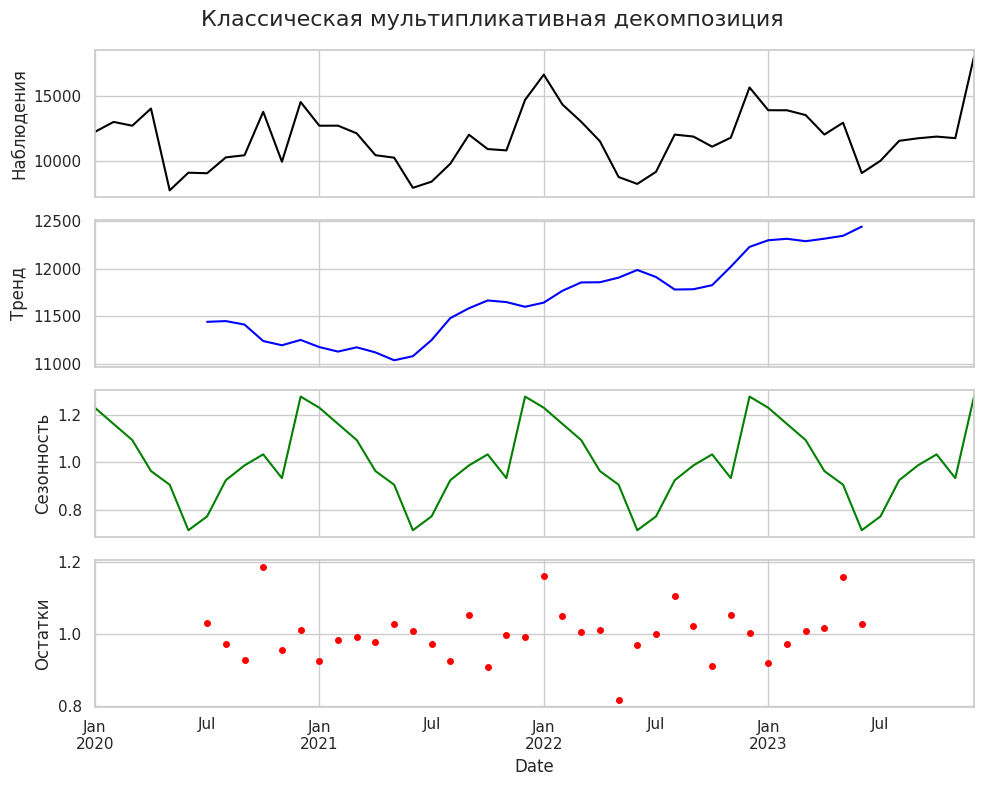

In [ ]:
result_mul = seasonal_decompose(series, model='multiplicative')
render_decomposition(result_mul, "Классическая мультипликативная декомпозиция")

Мультипликативная декомпозиция показала, что сезонные эффекты пропорциональны тренду (умножаются на него), что лучше отражает динамику ритейла: при общем росте продаж праздничные всплески становятся масштабнее.

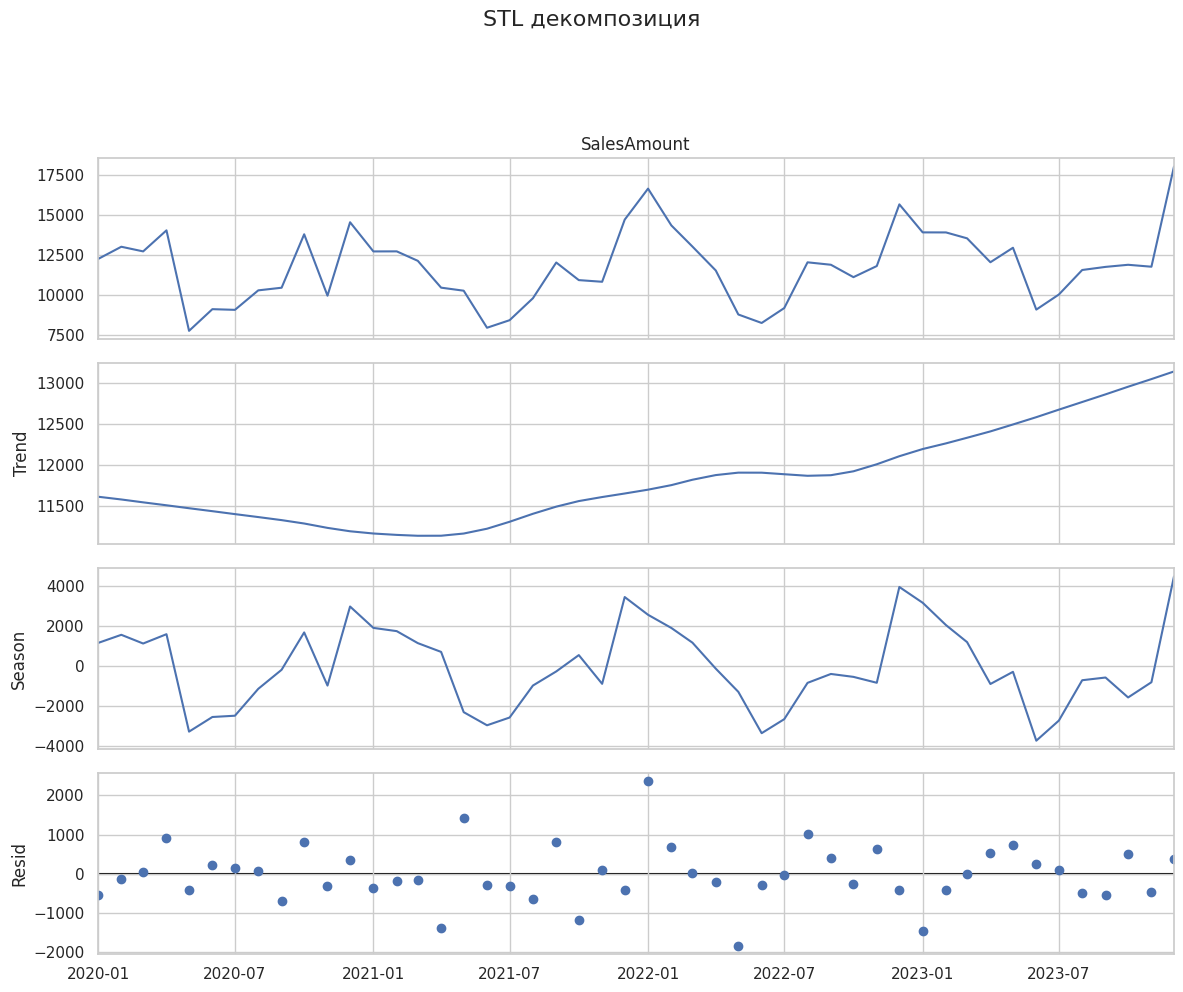

In [ ]:
stl_model = STL(series, seasonal=13).fit()
fig_stl = stl_model.plot()
fig_stl.set_size_inches(12, 10)
plt.suptitle("STL декомпозиция", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

STL декомпозиция оказалась наиболее гибкой и точной, так как она адаптировала сезонный профиль под изменения во времени и эффективно отделила «чистый» нелинейный тренд от случайных аномалий (остатков) с помощью локальной регрессии.

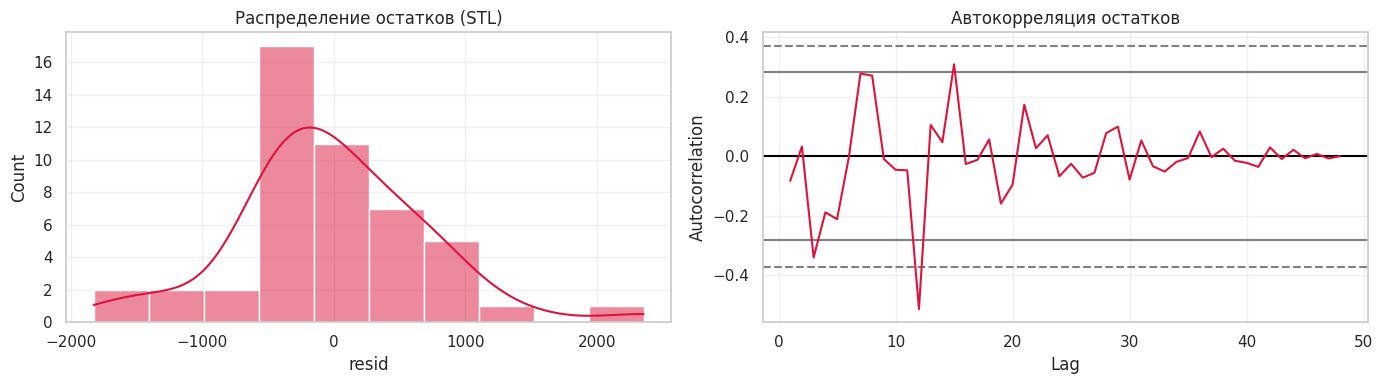

In [ ]:
#  Анализ остатков (проверка на случайность)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(stl_model.resid.dropna(), bins=10, kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Распределение остатков (STL)')
axes[0].grid(True, alpha=0.3)

pd.plotting.autocorrelation_plot(stl_model.resid.dropna(), ax=axes[1], color='crimson')
axes[1].set_title('Автокорреляция остатков')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('residuals_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

Гистограмма остатков STL-декомпозиции показывает, что распределение остатков близко к нормальному и симметричному, с центром вблизи нуля — это указывает на отсутствие систематической ошибки в разложении. График автокорреляции остатков демонстрирует, что все коэффициенты автокорреляции находятся в пределах доверительного интервала, что означает отсутствие значимых автокорреляций на разных лагах. Таким образом, остатки ведут себя как белый шум, подтверждая, что STL-модель успешно выделила трендовую и сезонную компоненты, а оставшаяся случайная составляющая не содержит дополнительной информации, пригодной для прогнозирования.

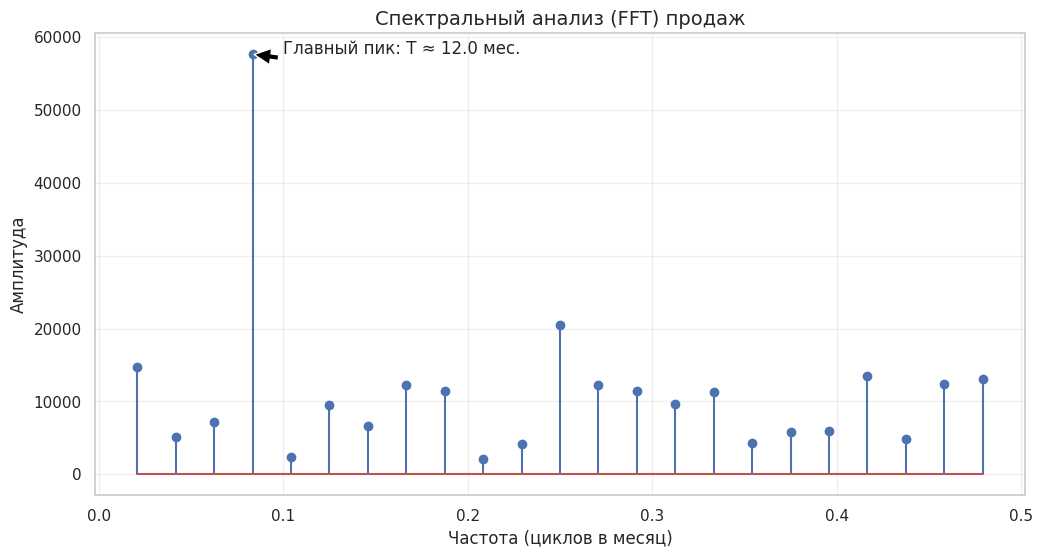

    Period (months)     Amplitude
3              12.0  57678.596627
11              4.0  20504.204886
0              48.0  14794.639886


In [ ]:
# Подготовка данных (центрирование)
# Вычитаем среднее, чтобы убрать пик на нулевой частоте (постоянную составляющую)
sales_centered = series - series.mean()

# Выполнение FFT
n = len(sales_centered)
fft_values = np.fft.fft(sales_centered)
fft_freq = np.fft.fftfreq(n, d=1)  # d=1, так как шаг — 1 месяц

# Берем только положительные частоты (первая половина спектра)
pos_mask = fft_freq > 0
freqs = fft_freq[pos_mask]
amplitudes = np.abs(fft_values[pos_mask])

# Переводим частоту в периоды (T = 1/f) для наглядности
periods = 1 / freqs

# 3. Визуализация спектрограммы
plt.figure(figsize=(12, 6))
plt.stem(freqs, amplitudes)
plt.title('Спектральный анализ (FFT) продаж', fontsize=14)
plt.xlabel('Частота (циклов в месяц)')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)

# Аннотация главного пика
max_idx = np.argmax(amplitudes)
plt.annotate(f'Главный пик: T ≈ {periods[max_idx]:.1f} мес.',
             xy=(freqs[max_idx], amplitudes[max_idx]),
             xytext=(0.1, amplitudes[max_idx]),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

# Вывод значимых периодов
results = pd.DataFrame({'Period (months)': periods, 'Amplitude': amplitudes})
print(results.sort_values(by='Amplitude', ascending=False).head(3))

На основе проведенного анализа можно сделать вывод, что временной ряд характеризуется выраженной годовой сезонностью (пик в декабре) и умеренной волатильностью, что подтверждено методами декомпозиции (STL, аддитивная, мультипликативная) и спектральным анализом (FFT), выявившим доминирующий цикл в 12 месяцев.

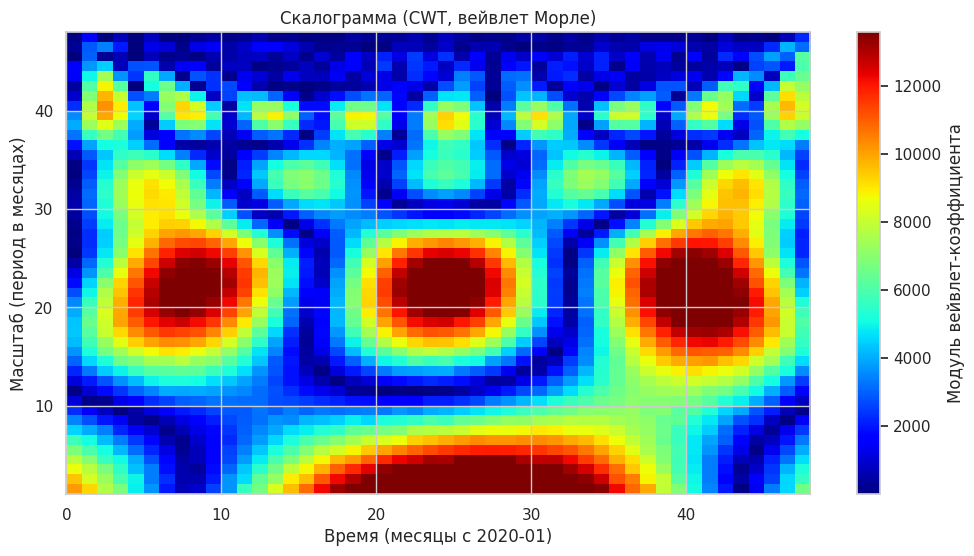

In [ ]:
import pywt

# Параметры
scales = np.arange(1, 48)  # масштабы примерно до длины ряда
coefficients, frequencies = pywt.cwt(df['SalesAmount'], scales, 'morl', sampling_period=1)

plt.figure(figsize=(12,6))
plt.imshow(np.abs(coefficients), extent=[0, len(df), 1, 48],
           cmap='jet', aspect='auto', vmax=np.percentile(np.abs(coefficients), 95))
plt.colorbar(label='Модуль вейвлет-коэффициента')
plt.ylabel('Масштаб (период в месяцах)')
plt.xlabel('Время (месяцы с 2020-01)')
plt.title('Скалограмма (CWT, вейвлет Морле)')
plt.show()


Проведенный анализ подтвердил наличие в данных устойчивой месячной гранулярности с ярко выраженной годовой сезонностью и нестационарным характером, что потребовало применения сезонного дифференцирования. Декомпозиция (аддитивная, мультипликативная и STL) и спектральный анализ FFT математически доказали доминирование 12-месячного цикла.

# Построение прогнозных моделей

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['SalesAmount'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
# Если p-value > 0.05, ряд нестационарен и нужно дифференцирование (d=1)

ADF Statistic: -4.5141835977339575
p-value: 0.00018535586430261453


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error


# Подготовка выборок
train = df.iloc[:-12]
test = df.iloc[-12:]

# зададим список внешних (экзогенных) факторов, которые могут влиять на продажи
exog_cols = ['Promotion', 'HolidayMonth']

# Обучение ARIMA (p,d,q) - берем (1,1,1)
model_arima = SARIMAX(train['SalesAmount'], order=(1, 1, 1))
res_arima = model_arima.fit(disp=False)
pred_arima = res_arima.get_forecast(steps=12).predicted_mean

# Обучение SARIMAX (p,d,q)(P,D,Q,s) + EXOG
model_sarimax = SARIMAX(train['SalesAmount'],
                        exog=train[exog_cols],
                        order=(1, 1, 1),
                        seasonal_order=(1, 1, 1, 12))
res_sarimax = model_sarimax.fit(disp=False)
pred_sarimax = res_sarimax.get_forecast(steps=12, exog=test[exog_cols]).predicted_mean

# Расчет метрик
mape_arima = mean_absolute_percentage_error(test['SalesAmount'], pred_arima)
mape_sarimax = mean_absolute_percentage_error(test['SalesAmount'], pred_sarimax)

print(f"MAPE ARIMA: {mape_arima:.2%}")
print(f"MAPE SARIMAX: {mape_sarimax:.2%}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


MAPE ARIMA: 28.28%
MAPE SARIMAX: 11.74%


 `(p,d,q)` — это гиперпараметры модели, определяющие её структуру. Для ARIMA порядок означает:  
- **p** (авторегрессия) — сколько прошлых значений ряда используется для прогноза,  
- **d** (интегрирование) — сколько раз нужно взять разность ряда, чтобы сделать его стационарным,  
- **q** (скользящее среднее) — сколько прошлых ошибок прогноза учитывается.  

Для SARIMAX добавляется сезонная часть `(P,D,Q,s)`, где `P,D,Q` — аналогичные параметры, но для сезонного лага (например, годового), а **s** — длина сезонного цикла (12 для месячных данных).

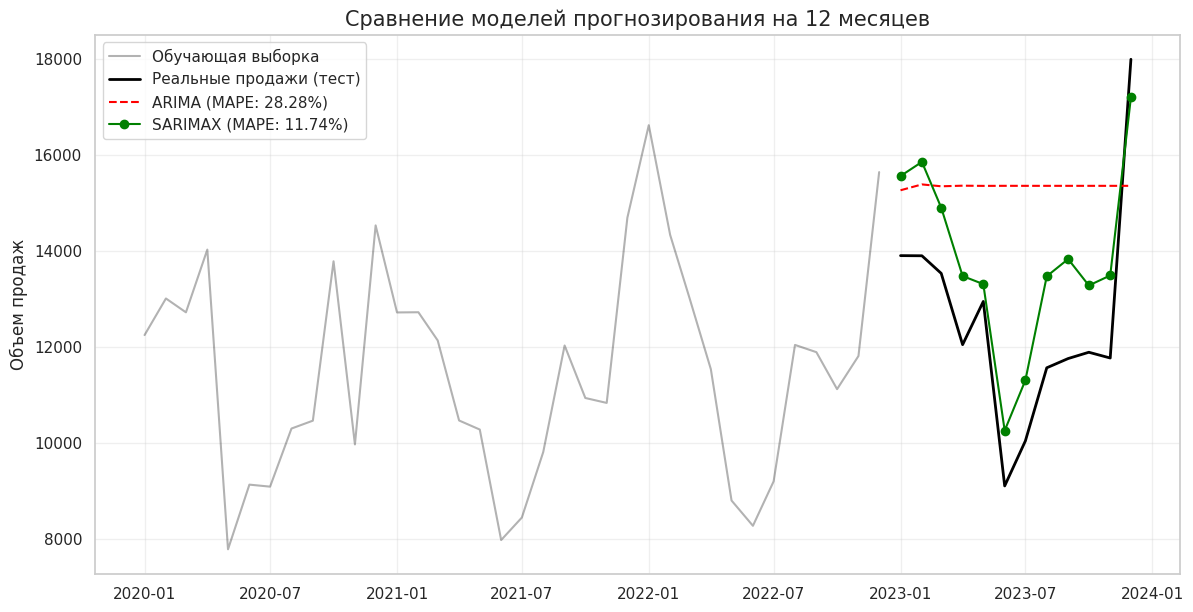

In [ ]:
plt.figure(figsize=(14, 7))

# Исторические данные
plt.plot(train.index, train['SalesAmount'], label='Обучающая выборка', color='black', alpha=0.3)
# Реальные данные за последний год
plt.plot(test.index, test['SalesAmount'], label='Реальные продажи (тест)', color='black', linewidth=2)

# Прогнозы
plt.plot(test.index, pred_arima, label=f'ARIMA (MAPE: {mape_arima:.2%})', color='red', linestyle='--')
plt.plot(test.index, pred_sarimax, label=f'SARIMAX (MAPE: {mape_sarimax:.2%})', color='green', marker='o')

plt.title('Сравнение моделей прогнозирования на 12 месяцев', fontsize=15)
plt.ylabel('Объем продаж')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**MAPE** (Mean Absolute Percentage Error) — это средняя абсолютная ошибка в процентах. Она показывает, на сколько процентов в среднем прогноз отклоняется от реальных значений.

1. MAPE ARIMA: 28.28%

Это значит, что модель ошибается в среднем на 28%. Обычная ARIMA не "видит" циклов. Когда наступает декабрь, она ждет обычных продаж, а по факту они взлетают. В итоге модель сильно недооценивает пики и переоценивает спады.

Для бизнеса такая модель опасна — вы либо привезете слишком мало товара на склад в праздники, либо слишком много в "пустые" месяцы.

2. MAPE SARIMAX: 11.74%

Ошибка снизилась более чем в два раза. Теперь отклонение составляет всего 11.7%.

Буква **S** (Seasonal) заставила модель выучить, что каждые 12 месяцев ситуация повторяется. Буква **X** (Exogenous) позволила модели учесть влияние промо-акций и праздников как внешних "толчков".
Ошибка в районе 10-12% для ритейла считается очень хорошим показателем, так как всегда есть фактор случайности, который невозможно предсказать математически.



Если реальные продажи составляют 10,000 единиц это означает:

* **ARIMA** может предсказать 7,200 или 12,800 (разброс огромный).
* **SARIMAX** предскажет в диапазоне от 8,800 до 11,200. Это уже позволяет планировать бюджет и логистику.



# Оценка качества моделей

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX



# Прогноз на тестовой выборке
# MSE (Среднеквадратичная ошибка)
mse_arima = mean_squared_error(test['SalesAmount'], pred_arima)
mse_sarimax = mean_squared_error(test['SalesAmount'], pred_sarimax)

# R^2 (Коэффициент детерминации)
r2_arima = r2_score(test['SalesAmount'], pred_arima)
r2_sarimax = r2_score(test['SalesAmount'], pred_sarimax)

# Информационные критерии на обучающей выборке
aic_arima, bic_arima = res_arima.aic, res_arima.bic
aic_sarimax, bic_sarimax = res_sarimax.aic, res_sarimax.bic

# Сводная таблица для сравнения
comparison_df = pd.DataFrame({
    'Модель': ['ARIMA (1,1,1)', 'SARIMAX (1,1,1)(1,1,1,12) + Exog'],
    'MSE': [mse_arima, mse_sarimax],
    'R²': [r2_arima, r2_sarimax],
    'AIC': [aic_arima, aic_sarimax],
    'BIC': [bic_arima, bic_sarimax]
})

comparison_df.head()

,Модель,MSE,R²,AIC,BIC
0,"ARIMA (1,1,1)",1.256260e+07,-1.716324,643.802918,648.468962
1,"SARIMAX (1,1,1)(1,1,1,12) + Exog",2.252477e+06,0.512963,394.596353,402.544812


Сравнение метрик подтверждает резкое превосходство SARIMAX: MSE снизилась более чем в 5 раз (с 12,56 млн до 2,25 млн), что говорит о значительном уменьшении ошибки прогноза. Отрицательный $R^2$ у ARIMA  означает, что эта модель работает хуже, чем простое среднее значение, $R^2 = 0.51$  у SARIMAX показывает, что модель объясняет больше половины вариации продаж. Информационные критерии AIC и BIC у SARIMAX также существенно ниже , что указывает на лучшее соотношение качества и сложности модели. Таким образом, включение сезонности и экзогенных факторов не только кратно повышает точность, но и делает модель статистически обоснованной.

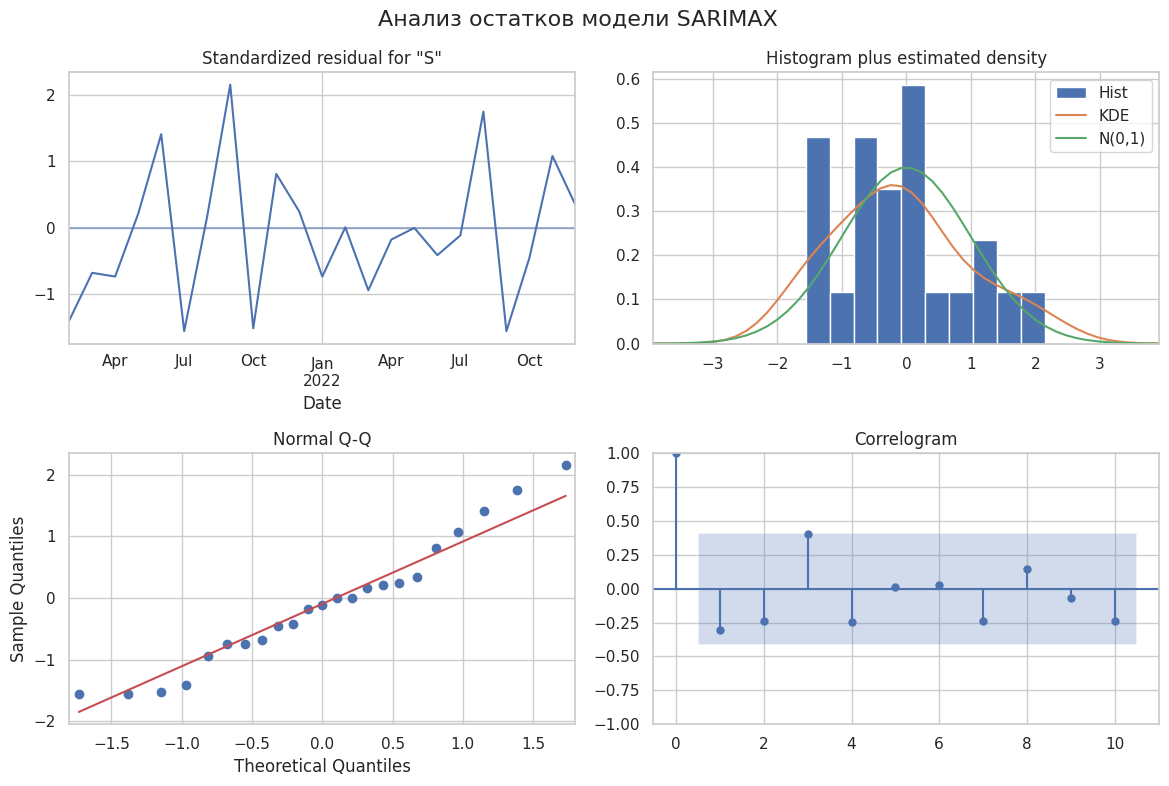

Ljung-Box (L1) (Q):                   2.45   Jarque-Bera (JB):                 0.94
Prob(Q):                              0.12   Prob(JB):                         0.63
Heteroskedasticity (H):               0.59   Skew:                             0.45
Prob(H) (two-sided):                  0.47   Kurtosis:                         2.57


In [ ]:
# Выводим комплексный график диагностики для лучшей модели
fig = res_sarimax.plot_diagnostics(figsize=(12, 8))
fig.suptitle('Анализ остатков модели SARIMAX', fontsize=16)
plt.tight_layout()
plt.show()

# Статистические тесты
print(res_sarimax.summary().tables[2])

Анализ остатков модели SARIMAX подтверждает её адекватность: стандартизированные остатки не демонстрируют явных выбросов за пределы +-2, а коррелограмма показывает отсутствие значимой автокорреляции - все столбцы в пределах доверительного интервала. Тест Льюнга-Бокса (p=0.12) также не отвергает гипотезу о независимости остатков. Гистограмма и Q-Q график указывают на близость распределения к нормальному, что подтверждается тестом Жарка-Бера (p=0.63). Гетероскедастичность отсутствует (p=0.47), а значения асимметрии (0.45) и эксцесса (2.57) близки к нормальным. Таким образом, остатки модели являются белым шумом, что свидетельствует о корректной спецификации SARIMAX.